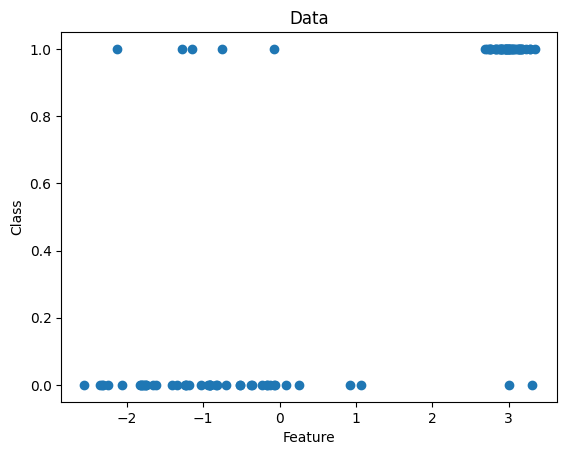

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

X, y = make_classification(
    n_samples=100, n_features=1, n_informative=1,
    n_redundant=0, n_repeated=0, n_classes=2,
    n_clusters_per_class=1, weights=[0.5,0.5],
    flip_y=0.15, class_sep=2.0, hypercube=True,
    shift=1.0, scale=1.0, shuffle=True, random_state=88
)

plt.scatter(X, y)
plt.xlabel("Feature")
plt.ylabel("Class")
plt.title("Data")
plt.show()

In [5]:
clf = LogisticRegression()
clf.fit(X, y)

print("Intercept: ", clf.intercept_)
print("Coefficient: ", clf.coef_)

Intercept:  [-0.98497516]
Coefficient:  [[1.18885765]]


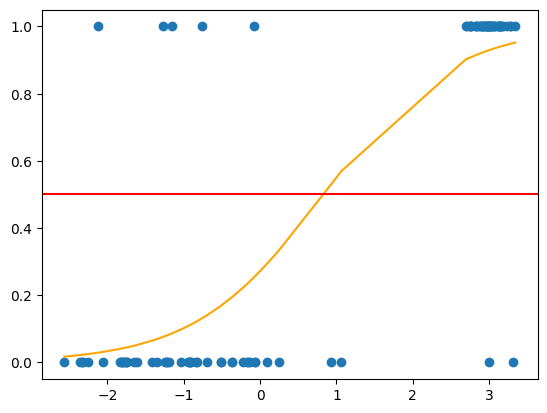

In [12]:
# X is 2D shape (100,1), we need 1D for plotting
X_plot = X.reshape(1, -1)[0]
X_sorted = np.sort(X_plot)

# Compute the sigmoid curve using what the model learned
p = 1 / (1 + np.exp(-(clf.coef_[0][0] * X_sorted + clf.intercept_[0])))

plt.scatter(X_plot, y, label="data")
plt.plot(X_sorted, p, color='orange', label="sigmoid")
plt.axhline(0.5, color='red',  label="p=0.5")
#plt.legend()
plt.show()

In [14]:
def predict_probability(coefs, X):
    '''
    coefs is a list that contains a and b: [coef, intercept]
    X is the features set
    Returns probability of X
    '''
    a, b = coefs[0], coefs[1]
    probabilities = 1 / (1 + np.exp(-(a * X + b)))
    return probabilities

# Verify it matches sklearn
our_probs = predict_probability(
    [clf.coef_[0][0], clf.intercept_[0]],
    X.reshape(1, -1)[0]
)
sklearn_probs = clf.predict_proba(X)[:, 1]

print("Ours:   ", our_probs[:5])
print("Sklearn:", sklearn_probs[:5])

Ours:    [0.16838474 0.93807876 0.08040988 0.92079705 0.93517695]
Sklearn: [0.16838474 0.93807876 0.08040988 0.92079705 0.93517695]


In [16]:
def predict_class(coefs, X):
    probs = predict_probability(coefs, X)
    return (probs >= 0.5).astype(int)

# Verify
our_classes = predict_class(
    [clf.coef_[0][0], clf.intercept_[0]],
    X.reshape(1, -1)[0]
)
sklearn_classes = clf.predict(X)

print("Ours:   ", our_classes[:5])
print("Sklearn:", sklearn_classes[:5])

Ours:    [0 1 0 1 1]
Sklearn: [0 1 0 1 1]


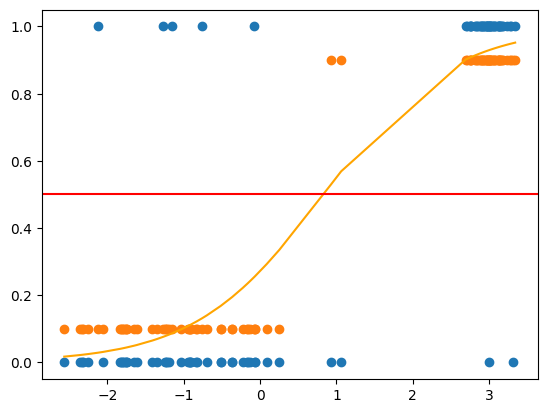

In [31]:
X_plot = X.reshape(1, -1)[0]
X_sorted = np.sort(X_plot)
p = 1 / (1 + np.exp(-(clf.coef_[0][0] * X_sorted + clf.intercept_[0])))

predicted = predict_class(
    [clf.coef_[0][0], clf.intercept_[0]], X_plot
)

plt.scatter(X_plot, y,  label="data")
plt.plot(X_sorted, p, color='orange', label="sigmoid")
plt.axhline(0.5, color='red',  label="p=0.5")
# Shift predictions slightly so they don't overlap with actual labels
plt.scatter(X_plot, predicted * 0.8 + 0.1, 
              label="predicted")
#plt.legend()
plt.show()

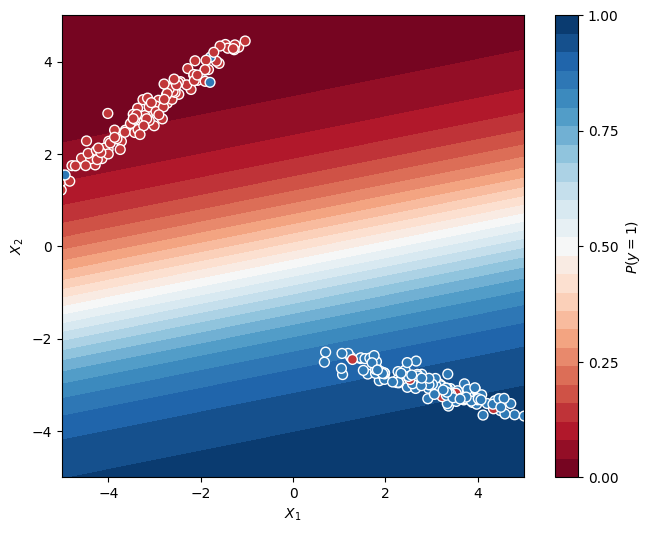

In [32]:
X, y = make_classification(n_features=2, n_redundant=0,
                           n_samples=250, n_classes=2,
                           n_clusters_per_class=1,
                           flip_y=0.05, class_sep=3,
                           random_state=43)

clf = LogisticRegression()
clf.fit(X, y)

# Provided plotting code — creates a grid and colors each point
# by its predicted probability
xx, yy = np.mgrid[-5:5:.01, -5:5:.01] # generates numbers from -5 to 5 in steps of 0.01. That's 1000 values per axis.

grid = np.c_[xx.ravel(), yy.ravel()] # generates a 2D grid
probs = clf.predict_proba(grid)[:, 1].reshape(xx.shape)

f, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(xx, yy, probs, 25, cmap="RdBu", vmin=0, vmax=1)
ax_c = f.colorbar(contour)
ax_c.set_label("$P(y = 1)$")
ax_c.set_ticks([0, .25, .5, .75, 1])

ax.scatter(X[:,0], X[:, 1], c=y, s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white", linewidth=1)

ax.set(aspect="equal", xlim=(-5, 5), ylim=(-5, 5),
       xlabel="$X_1$", ylabel="$X_2$")
plt.show()